In [27]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyemu
import flopy

In [28]:
run_name = 'local2'
m_d = r'../models/local2/pest/master_ies'

# Phi

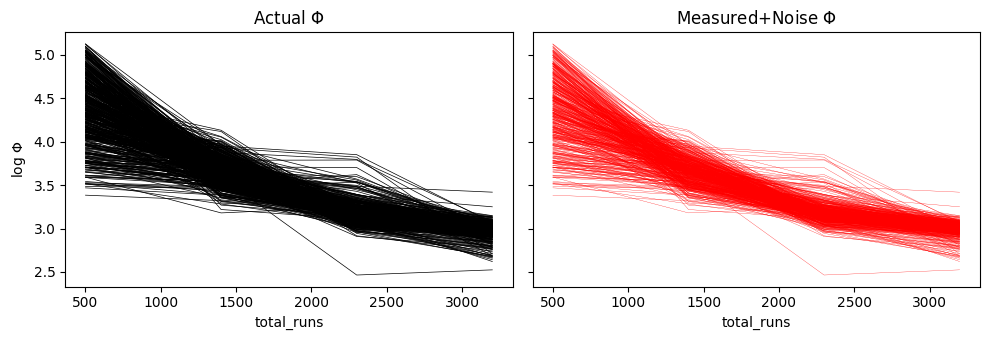

In [29]:
f_act = os.path.join(m_d, f"{run_name}.phi.actual.csv")
f_meas = os.path.join(m_d, f"{run_name}.phi.meas.csv")

fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10,3.5))
# left
ax = axes[0]
phi = pd.read_csv(f_act, index_col=0)
phi.index = phi.total_runs
phi.iloc[:,6:].apply(np.log10).plot(legend=False,lw=0.5,color='k', ax=ax)
ax.set_title(r'Actual $\Phi$')
ax.set_ylabel(r'log $\Phi$')
# right
ax = axes[-1]
phi = pd.read_csv(f_meas,index_col=0)
phi.index = phi.total_runs
phi.iloc[:,6:].apply(np.log10).plot(legend=False,lw=0.2,color='r', ax=ax)
ax.set_title(r'Measured+Noise $\Phi$')
fig.tight_layout()

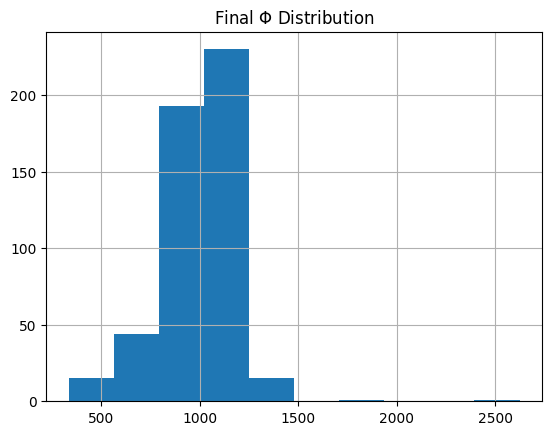

In [30]:
plt.figure()
phi.iloc[-1,6:].hist()
plt.title(r'Final $\Phi$ Distribution');

# Obs: Prior vs Posterior

In [31]:
pst = pyemu.Pst(os.path.join(m_d, f"{run_name}.pst"))
pr_oe = pyemu.ObservationEnsemble.from_csv(pst=pst,filename=os.path.join(m_d, f"{run_name}.0.obs.csv"))
pt_oe = pyemu.ObservationEnsemble.from_csv(pst=pst,filename=os.path.join(m_d, f"{run_name}.{pst.control_data.noptmax}.obs.csv"))
noise = pyemu.ObservationEnsemble.from_csv(pst=pst,filename=os.path.join(m_d,f"{run_name}.obs+noise.csv"))

## 1:1 plots

[<Figure size 800x1050 with 0 Axes>,
 <Figure size 800x1050 with 8 Axes>,
 <Figure size 800x1050 with 8 Axes>]

<Figure size 800x1050 with 0 Axes>

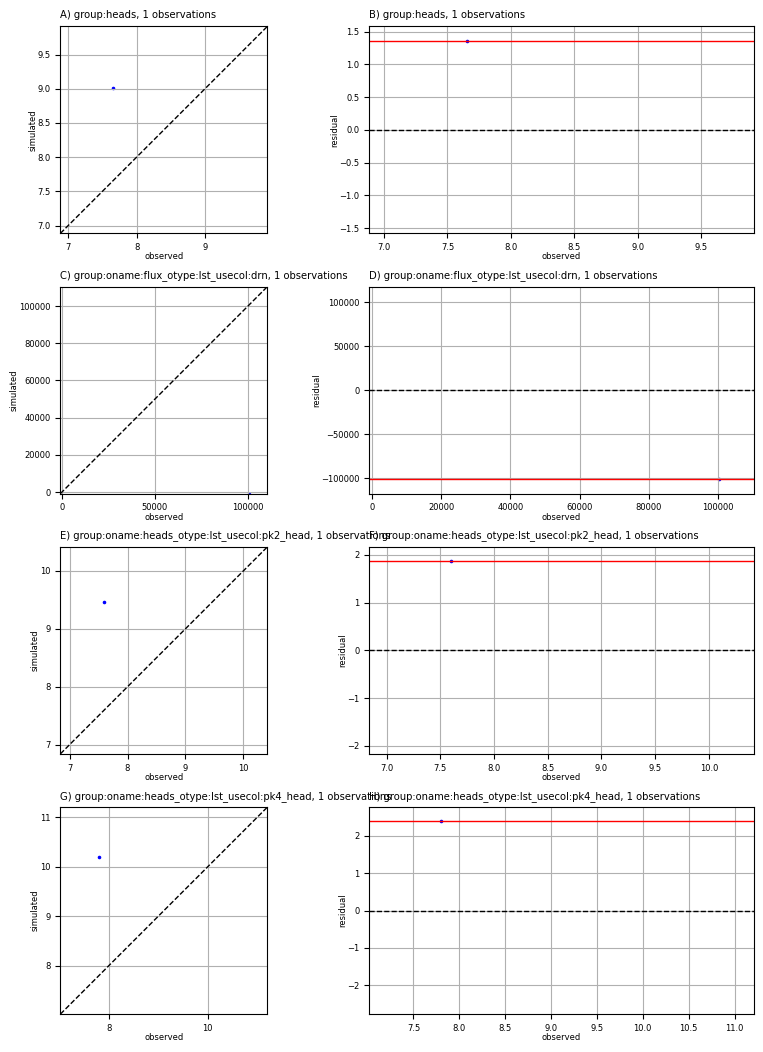

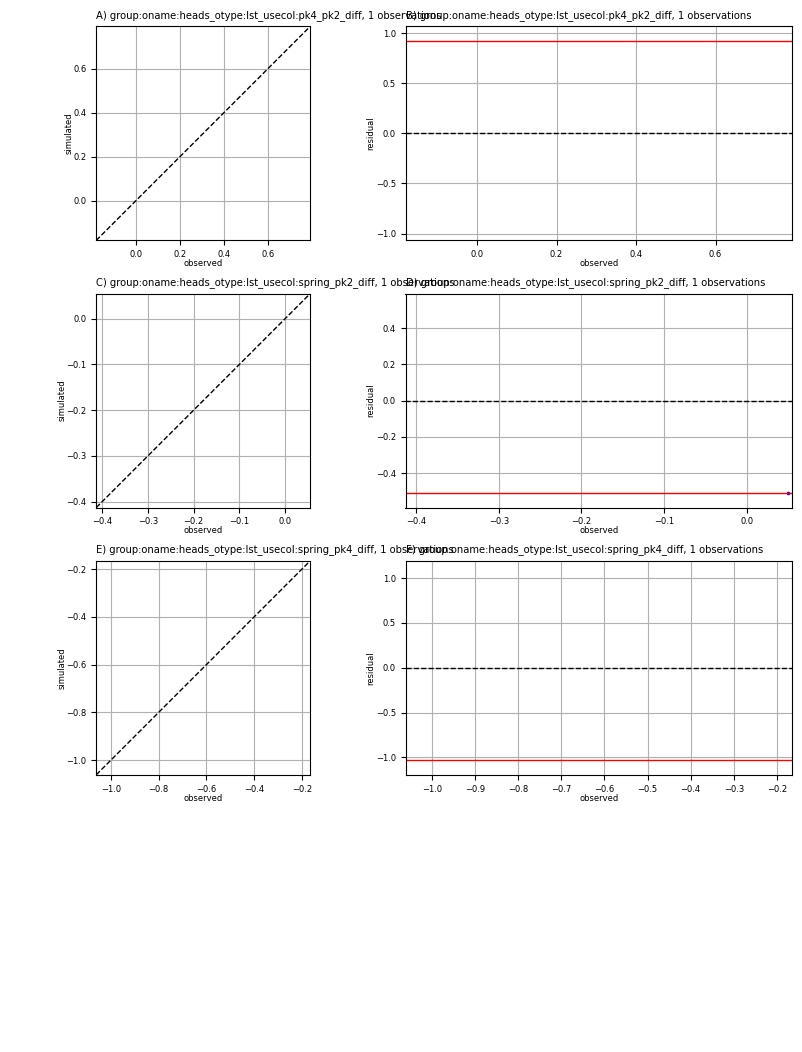

In [34]:
pst.plot('1to1')

## Phi

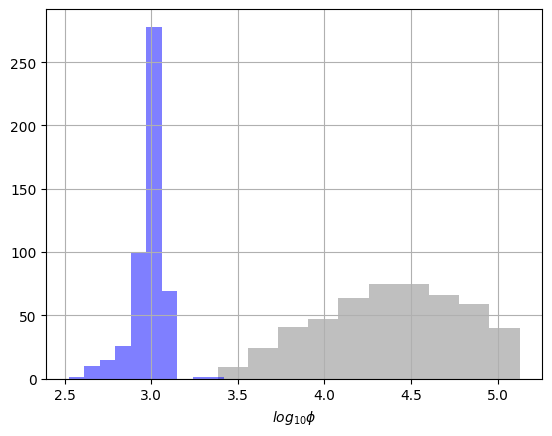

In [32]:
fig,ax = plt.subplots(1,1)
pr_oe.phi_vector.apply(np.log10).hist(ax=ax,fc="0.5",ec="none",alpha=0.5,density=False) # prior grey
pt_oe.phi_vector.apply(np.log10).hist(ax=ax,fc="b",ec="none",alpha=0.5,density=False) # posterior blue
_ = ax.set_xlabel("$log_{10}\\phi$")

reducing posterior ensemble from 500 to 450 realizations


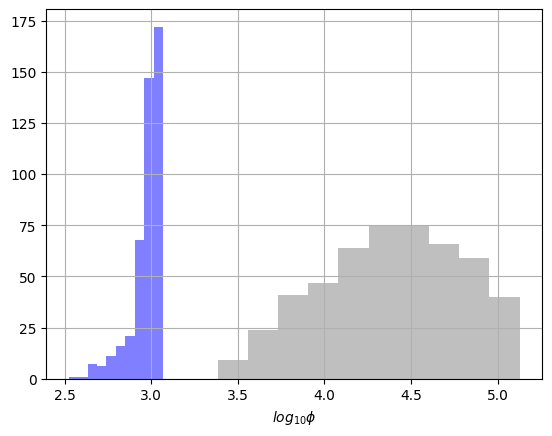

In [33]:
# threshold Phi
thres = phi.iloc[-1,6:].quantile(0.9)
# drop reals with Phi > thresh
pv = pt_oe.phi_vector
keep = pv.loc[pv<thres]
if keep.shape[0] != pv.shape[0]:
    print("reducing posterior ensemble from {0} to {1} realizations".format(pv.shape[0],keep.shape[0]))
    pt_oe = pt_oe.loc[keep.index,:]
    fig,ax = plt.subplots(1,1)
    pr_oe.phi_vector.apply(np.log10).hist(ax=ax,fc="0.5",ec="none",alpha=0.5,density=False)
    pt_oe.phi_vector.apply(np.log10).hist(ax=ax,fc="b",ec="none",alpha=0.5,density=False)
    _ = ax.set_xlabel("$log_{10}\\phi$")
else:
    print('No realizations dropped.')
if pt_oe.shape[0] == 0:
    print("filtered out all posterior realization #sad")

## Obs

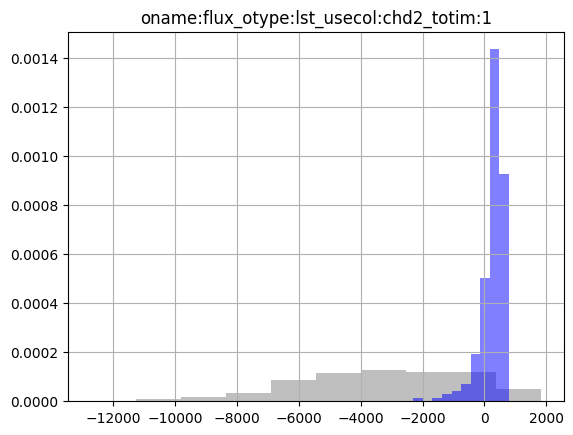

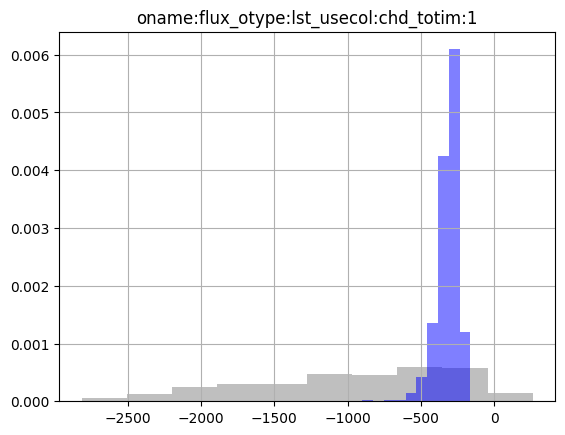

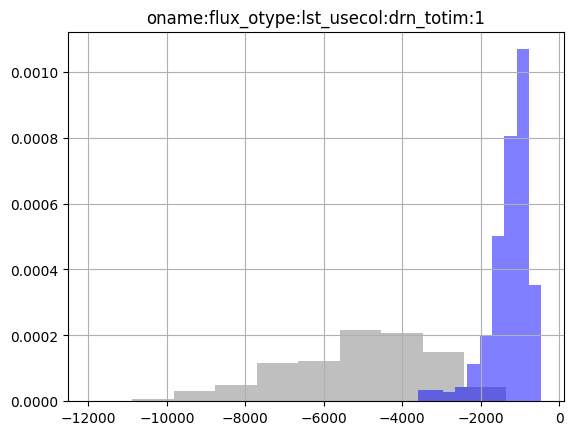

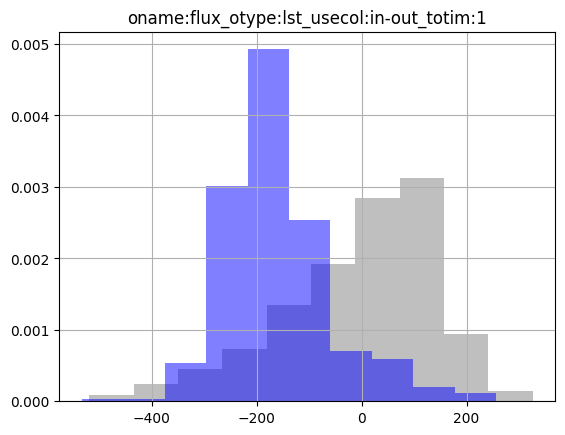

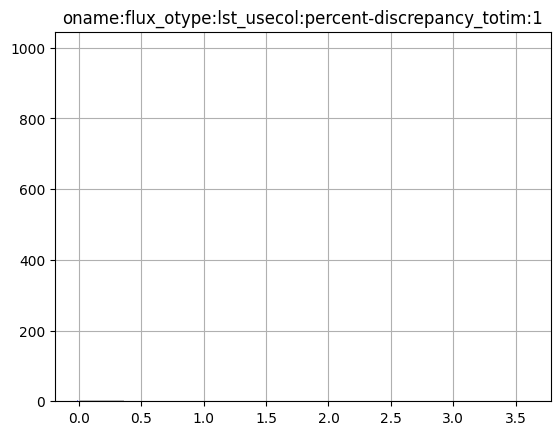

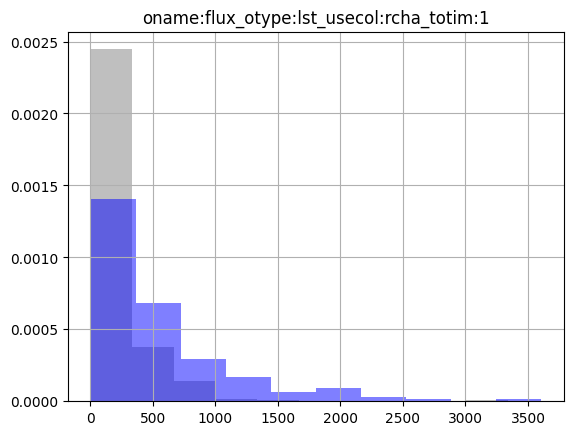

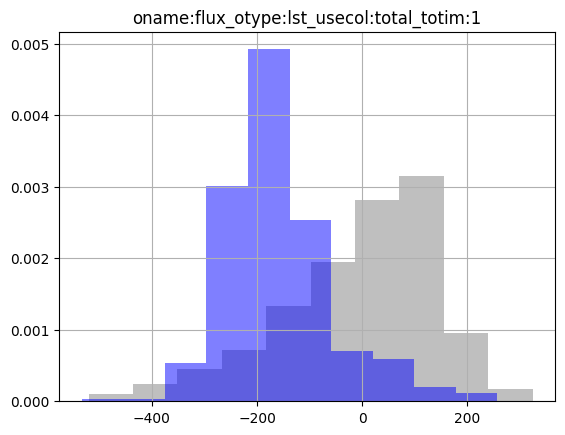

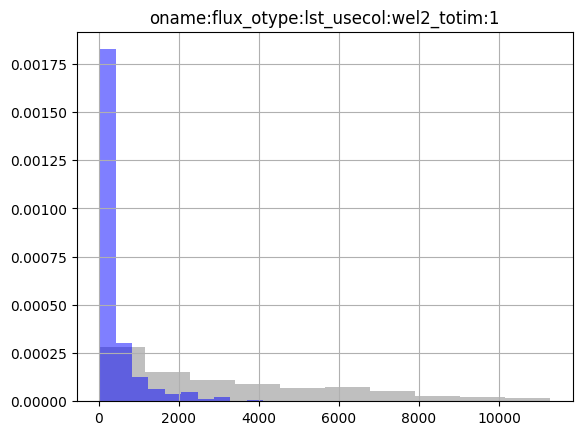

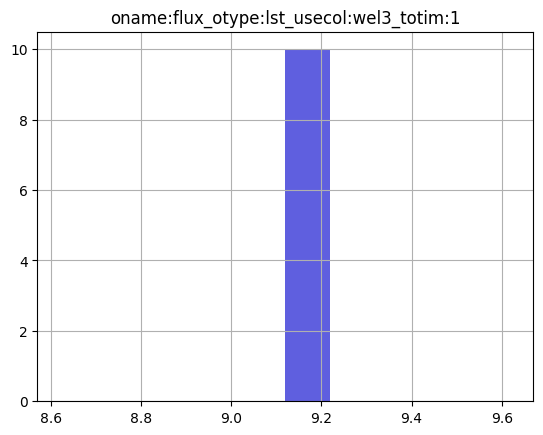

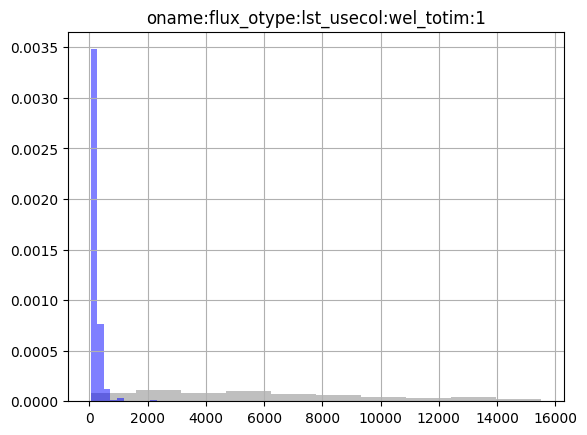

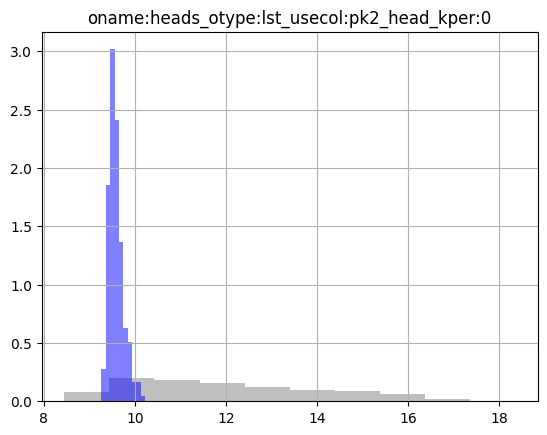

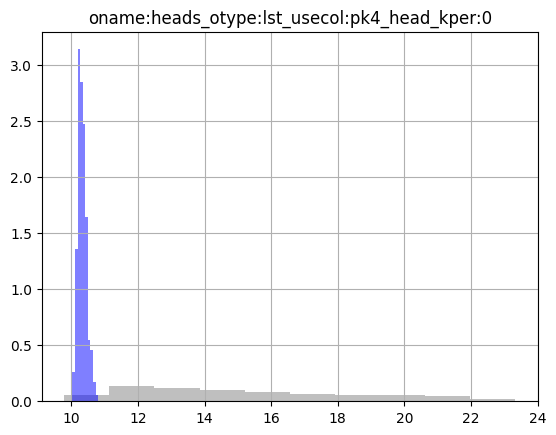

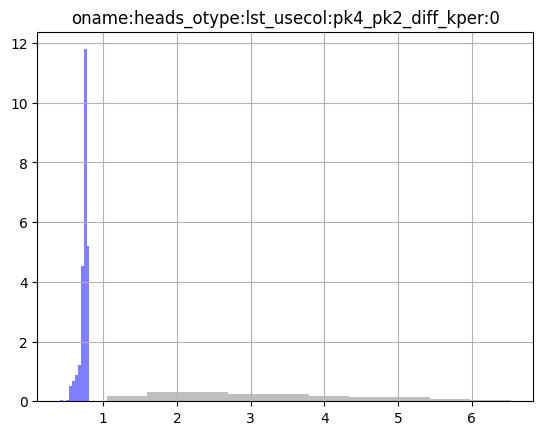

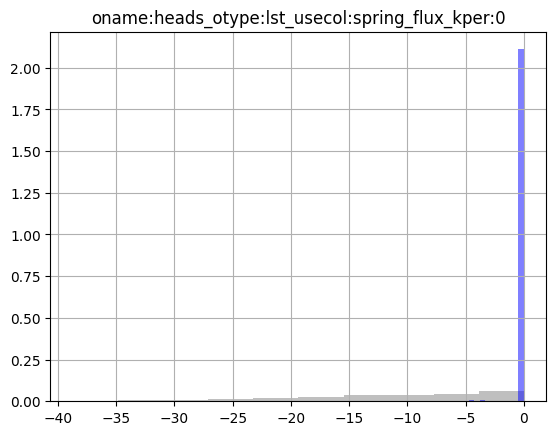

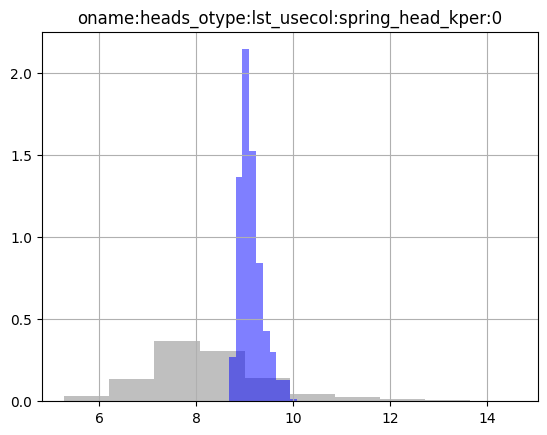

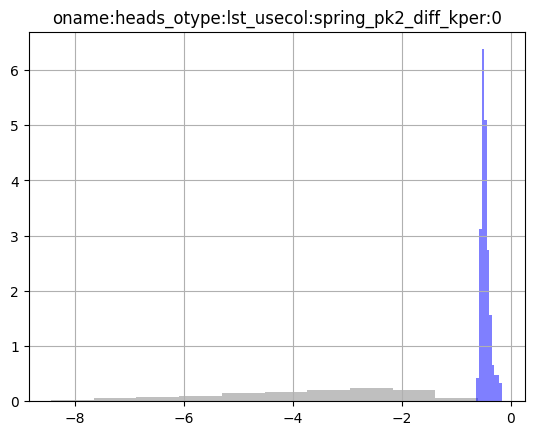

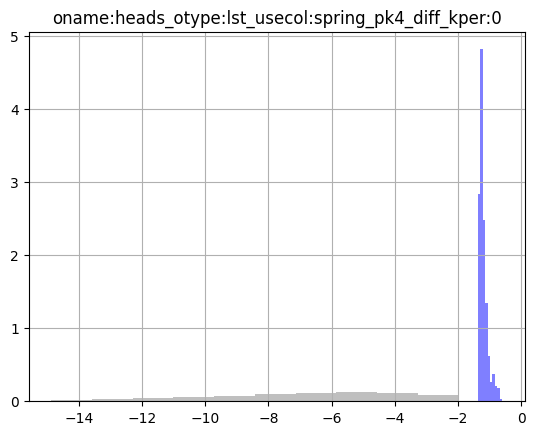

In [35]:
for col in pr_oe.columns:
    # plot the prior and posterior ensemble distributions
    fig, ax = plt.subplots(1, 1)
    pr_oe.loc[:, col].hist(ax=ax, fc="0.5", ec="none", alpha=0.5, density=True)  # prior grey
    pt_oe.loc[:, col].hist(ax=ax, fc="b", ec="none", alpha=0.5, density=True)  # posterior blue
    ax.set_title(col)
    plt.show()

# Params

In [54]:
pst = pyemu.Pst(os.path.join(m_d, f"{run_name}.pst"))
pr_oe = pyemu.ParameterEnsemble.from_csv(pst=pst,filename=os.path.join(m_d, f"{run_name}.0.par.csv"))
pt_oe = pyemu.ParameterEnsemble.from_csv(pst=pst,filename=os.path.join(m_d, f"{run_name}.{pst.control_data.noptmax}.par.csv"))

In [68]:
pr_oe_df

,pname:npfklayer5gr_inst:0_ptype:gr_pstyle:m_i:0_j:59_x:595.00_y:1205.00_zone:1,pname:npfklayer5gr_inst:0_ptype:gr_pstyle:m_i:0_j:60_x:605.00_y:1205.00_zone:1,pname:npfklayer5gr_inst:0_ptype:gr_pstyle:m_i:0_j:61_x:615.00_y:1205.00_zone:1,pname:npfklayer5gr_inst:0_ptype:gr_pstyle:m_i:0_j:62_x:625.00_y:1205.00_zone:1,pname:npfklayer5gr_inst:0_ptype:gr_pstyle:m_i:0_j:63_x:635.00_y:1205.00_zone:1,pname:npfklayer5gr_inst:0_ptype:gr_pstyle:m_i:0_j:64_x:645.00_y:1205.00_zone:1,pname:npfklayer5gr_inst:0_ptype:gr_pstyle:m_i:0_j:65_x:655.00_y:1205.00_zone:1,pname:npfklayer5gr_inst:0_ptype:gr_pstyle:m_i:0_j:66_x:665.00_y:1205.00_zone:1,pname:npfklayer5gr_inst:0_ptype:gr_pstyle:m_i:0_j:67_x:675.00_y:1205.00_zone:1,pname:npfklayer5gr_inst:0_ptype:gr_pstyle:m_i:0_j:68_x:685.00_y:1205.00_zone:1,...,pname:chd_conf_headgr_inst:0_ptype:gr_usecol:3_pstyle:a_idx0:9_idx1:116_idx2:101,pname:chd_conf_headgr_inst:0_ptype:gr_usecol:3_pstyle:a_idx0:9_idx1:117_idx2:99,pname:chd_conf_headgr_inst:0_ptype:gr_usecol:3_pstyle:a_idx0:9_idx1:117_idx2:100,pname:chd_conf_headgr_inst:0_ptype:gr_usecol:3_pstyle:a_idx0:9_idx1:118_idx2:99,pname:chd_conf_headgr_inst:0_ptype:gr_usecol:3_pstyle:a_idx0:9_idx1:118_idx2:100,pname:chd_conf_headgr_inst:0_ptype:gr_usecol:3_pstyle:a_idx0:9_idx1:119_idx2:99,pname:chd_conf_headgr_inst:0_ptype:gr_usecol:3_pstyle:a_idx0:9_idx1:119_idx2:100,pname:chd_conf_headgr_inst:0_ptype:gr_usecol:3_pstyle:a_idx0:9_idx1:120_idx2:99,pname:chd_conf_headgr_inst:0_ptype:gr_usecol:3_pstyle:a_idx0:9_idx1:120_idx2:100,pname:chd_conf_headcn_inst:0_ptype:cn_usecol:3_pstyle:a
real_name,,,,,,,,,,,,,,,,,,,,,
0,6.488341,2.817700,2.186336,2.502479,3.005544,6.194988,6.336142,3.648625,0.603668,0.501054,...,-0.319479,1.239736,0.299815,-0.485860,-1.710758,-0.862538,0.871887,0.757720,0.622854,-0.188561
1,0.040598,0.093096,0.121507,0.082005,0.037885,0.414053,0.467596,0.358665,0.414080,1.744232,...,-0.182787,-0.160577,0.724742,0.036253,0.337431,0.759885,-0.137731,0.379535,-0.054236,-0.441257
2,0.146792,0.351867,0.390592,0.277065,0.881668,0.307745,0.324169,0.908963,0.416553,0.160422,...,-0.540279,0.587510,-0.352475,-0.631415,0.385947,0.291341,0.027196,0.091964,0.708724,-1.536317
3,0.056614,0.065456,0.110641,0.069742,0.195100,0.087090,0.118207,0.671880,1.561439,6.787864,...,0.408611,-0.371206,-0.013191,-0.750675,0.165111,0.357592,1.050543,0.616233,0.933152,-1.521798
4,0.721459,2.276876,1.041051,0.481671,0.210040,0.254766,0.121326,0.040651,0.131551,0.089746,...,0.969306,0.454308,0.364111,-0.085047,0.373063,0.156768,-0.450429,1.499603,-0.179991,0.346830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,7.538177,2.853692,1.596926,0.575763,0.017514,0.059146,0.033666,0.046303,0.110662,0.252289,...,-1.292940,-0.544858,0.690068,-0.122153,-0.143867,-0.065574,0.204302,-1.033113,0.518273,-0.636771
496,1.191173,2.380047,2.113981,4.363465,2.626002,4.671659,4.820094,4.241951,2.179541,3.058956,...,0.842615,-0.718111,1.622096,-0.216425,0.449035,-0.057861,-0.471887,-0.212646,1.168325,-0.457662
497,0.123651,0.047254,0.101526,0.059621,0.105144,0.058715,0.188618,0.515393,0.163726,0.340919,...,0.772872,-0.416574,-0.398176,0.250344,1.051356,-0.168062,-0.900515,1.065714,0.039693,0.000821


<Axes: >

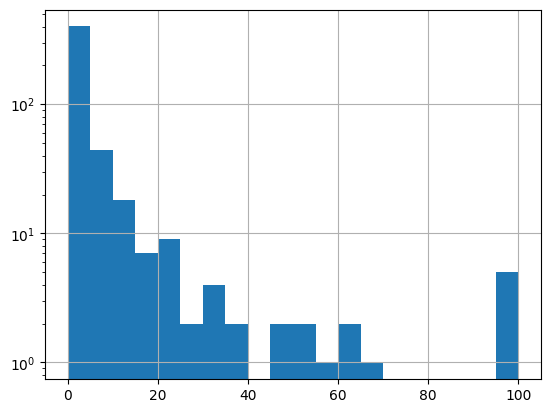

In [87]:
pr_oe_df = pr_oe._df
mask = pr_oe_df.columns.str.contains("npfklayer1")
cols = pr_oe_df.columns[mask]
pr_oe_df[cols[2]].hist(bins=20, log=True)

In [ ]:
pr_oe_df[cols[2]]

AttributeError: 'Series' object has no attribute 'log'

## using Mult to model

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package npf...
    loading package ic...
    loading package rch...
    loading package drn...
    loading package chd...
    loading package chd...
    loading package wel...
    loading package wel...
    loading package wel...
    loading package oc...
  loading solution package local2...


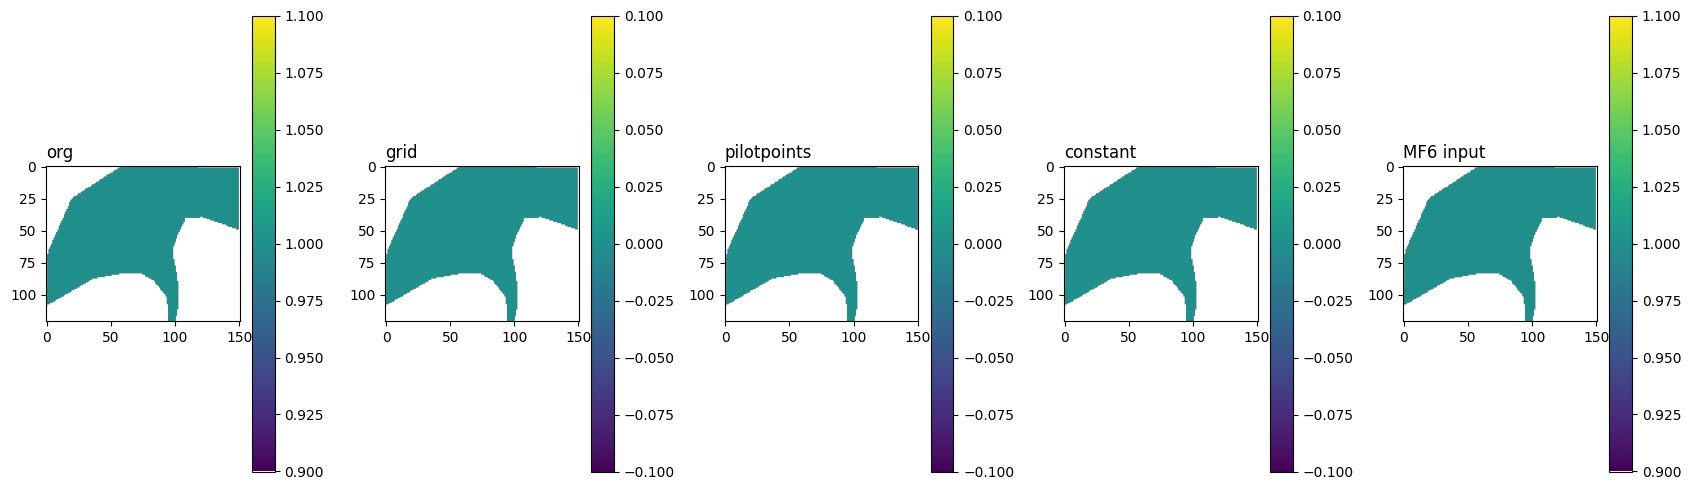

In [58]:
TEMP_DIR = r'../models/local2/pest/local2_template'
df = pd.read_csv(os.path.join(TEMP_DIR,"mult2model_info.csv"))
kh1_df = df.loc[df.model_file.str.contains("npf_k_layer4"),:]
sim = flopy.mf6.MFSimulation.load(sim_ws=m_d)
ib = sim.get_model().dis.idomain.array[0,:,:]

org_arr = np.loadtxt(os.path.join(TEMP_DIR,kh1_df.org_file.iloc[0]))
inp_arr = np.loadtxt(os.path.join(TEMP_DIR,kh1_df.model_file.iloc[0]))
mlt_arrs = [np.loadtxt(os.path.join(TEMP_DIR,afile)) for afile in kh1_df.mlt_file]
arrs = [org_arr]
arrs.extend(mlt_arrs)
arrs.append(inp_arr)
names = ["org"]
names.extend([mf.split('.')[0].split('_')[-1] for mf in kh1_df.mlt_file])
names.append("MF6 input")
fig,axes = plt.subplots(1,kh1_df.shape[0]+2,figsize=(5*kh1_df.shape[0]+2,5))
for i,ax in enumerate(axes.flatten()):
    arr = np.log10(arrs[i])
    arr[ib==0] = np.nan
    cb = ax.imshow(arr)
    plt.colorbar(cb,ax=ax)
    ax.set_title(names[i],loc="left")
plt.tight_layout()

In [60]:
kh1_df

,Unnamed: 0,org_file,model_file,use_cols,index_cols,fmt,sep,head_rows,upper_bound,lower_bound,...,mlt_file,zone_file,apply_order,fac_file,pp_file,pp_fill_value,pp_lower_limit,pp_upper_limit,chkpar,zero_based
9,9,org/local2.npf_k_layer4.txt,local2.npf_k_layer4.txt,NaN,NaN,%24.18E,NaN,0,1000.0,0.0001,...,mult/npfklayer4gr_inst0_grid.csv,npfklayer4gr_inst0_grid.csv.zone,999,NaN,NaN,NaN,NaN,NaN,NaN,False
10,10,org/local2.npf_k_layer4.txt,local2.npf_k_layer4.txt,NaN,NaN,%24.18E,NaN,0,1000.0,0.0001,...,mult/npfklayer4pp_inst0_pilotpoints.csv,npfklayer4pp_inst0pp.dat.zone,999,npfklayer5pp_inst0pp.fac,npfklayer4pp_inst0pp.dat,1.0,1.000000e-30,1.000000e+30,NaN,False
11,11,org/local2.npf_k_layer4.txt,local2.npf_k_layer4.txt,NaN,NaN,%24.18E,NaN,0,1000.0,0.0001,...,mult/npfklayer4cn_inst0_constant.csv,npfklayer4cn_inst0_constant.csv.zone,999,NaN,NaN,NaN,NaN,NaN,NaN,False


# Prior data conflict

In [42]:
pdc0 = os.path.join(m_d, f"{run_name}.0.pdc.csv")
#read
pdc = pd.read_csv(pdc0,index_col=0)

In [43]:
pdc

,obs_mean,obs_std,obs_min,obs_max,obs_stat_min,obs_stat_max,sim_mean,sim_std,sim_min,sim_max,sim_stat_min,sim_stat_max,distance
name,,,,,,,,,,,,,
oname:flux_otype:lst_usecol:drn_totim:1,100404.00,1.310980e-10,100404.00,100404.00,100404.00,100404.00,-5116.88000,1845.98000,-11946.90000,-1368.540000,-6962.87000,-3270.90000,101772.000000
oname:heads_otype:lst_usecol:pk2_head_kper:0,7.60,1.600320e-14,7.60,7.60,7.60,7.60,12.00160,2.08976,8.45290,18.348300,9.91185,14.09140,0.852895
oname:heads_otype:lst_usecol:pk4_head_kper:0,7.80,1.689230e-14,7.80,7.80,7.80,7.80,15.22420,3.31495,9.78740,23.325900,11.90920,18.53910,1.987400
oname:heads_otype:lst_usecol:pk4_pk2_diff_kper:0,-0.20,4.723170e-16,-0.20,-0.20,-0.20,-0.20,3.22257,1.33145,1.05173,6.530730,1.89112,4.55402,1.251730
oname:heads_otype:lst_usecol:spring_pk2_diff_kper:0,0.05,1.180790e-16,0.05,0.05,0.05,0.05,-3.77553,1.78029,-8.42896,-0.600441,-5.55582,-1.99524,0.650441
oname:heads_otype:lst_usecol:spring_pk4_diff_kper:0,-0.15,0.000000e+00,-0.15,-0.15,-0.15,-0.15,-6.99810,3.10169,-14.87090,-1.989220,-10.09980,-3.89641,1.839220


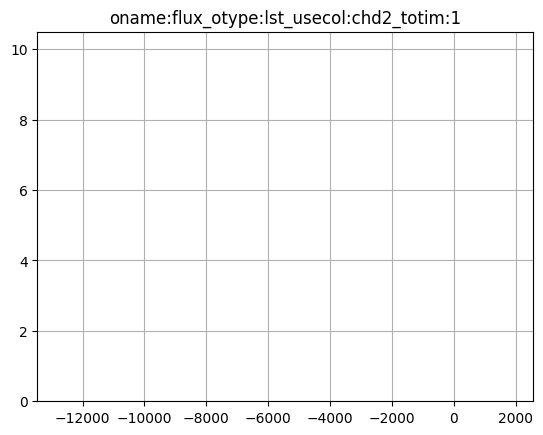

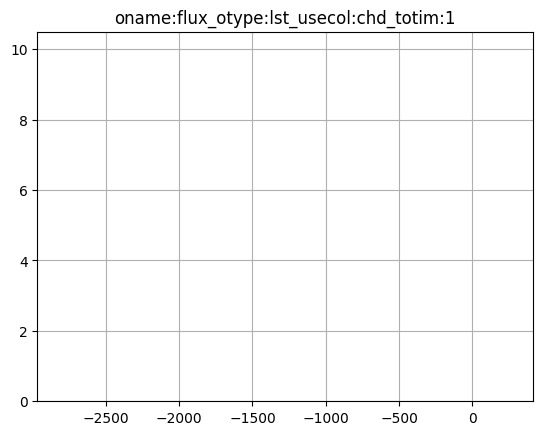

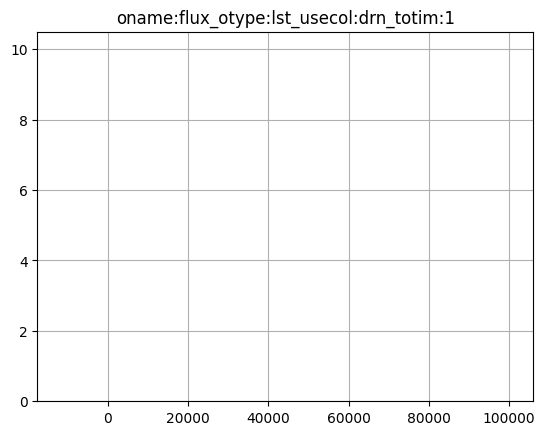

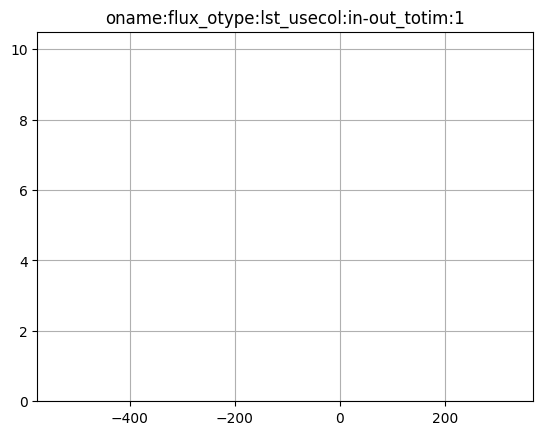

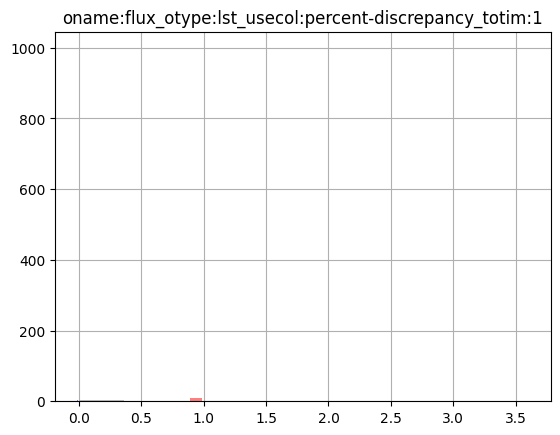

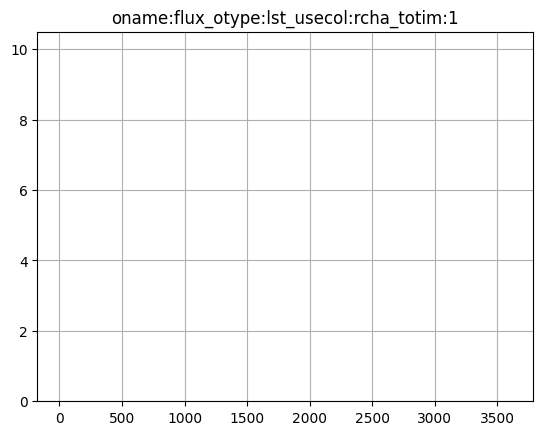

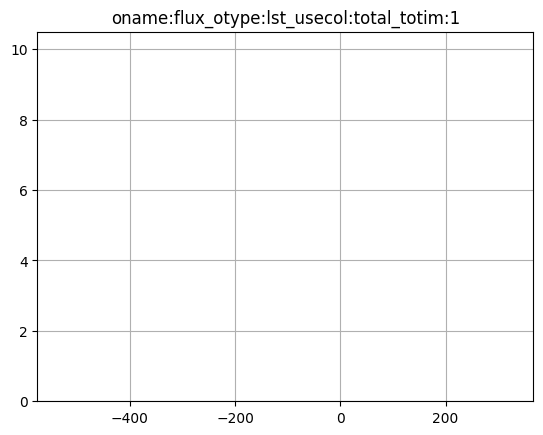

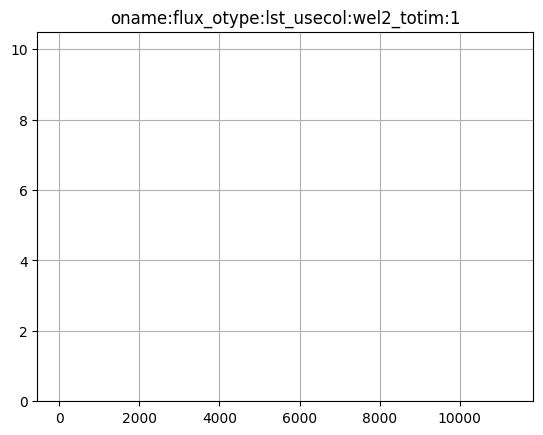

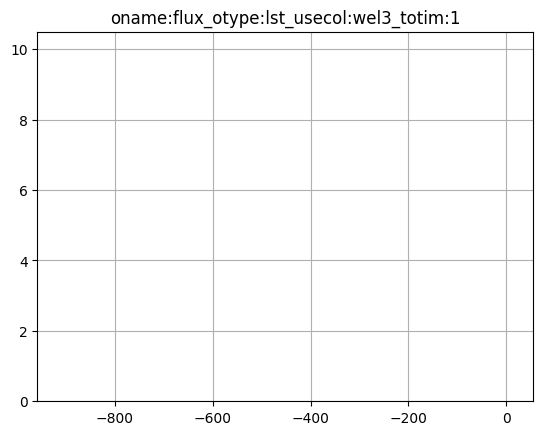

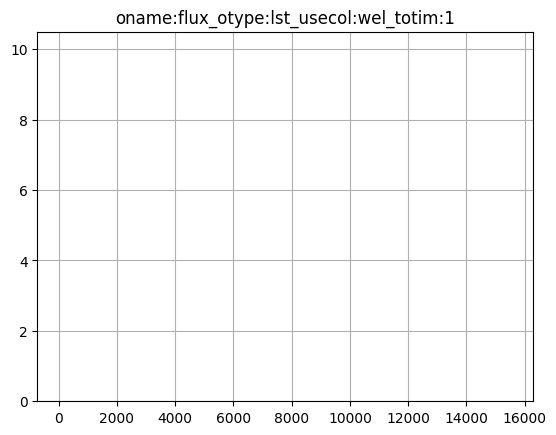

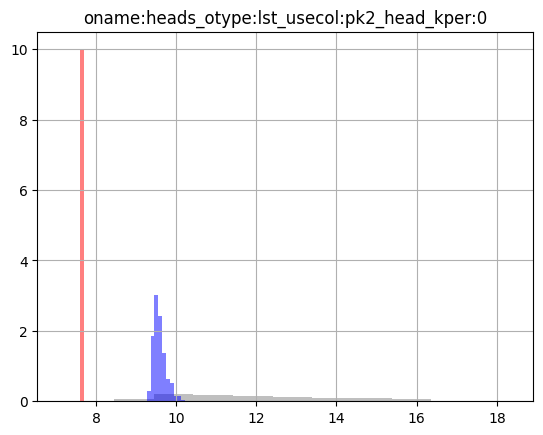

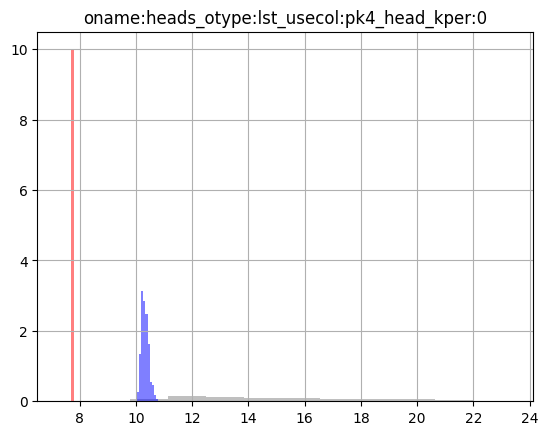

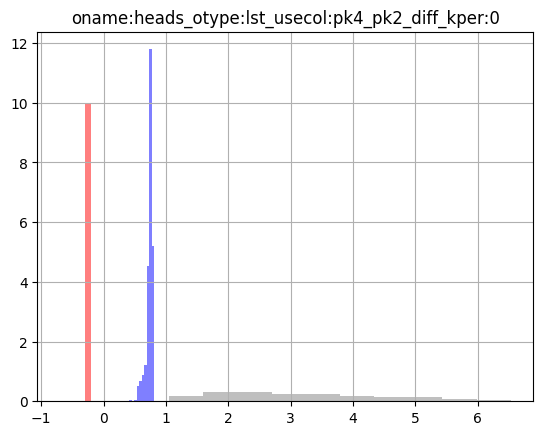

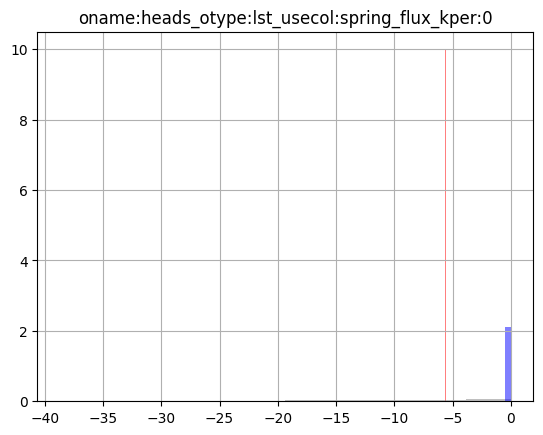

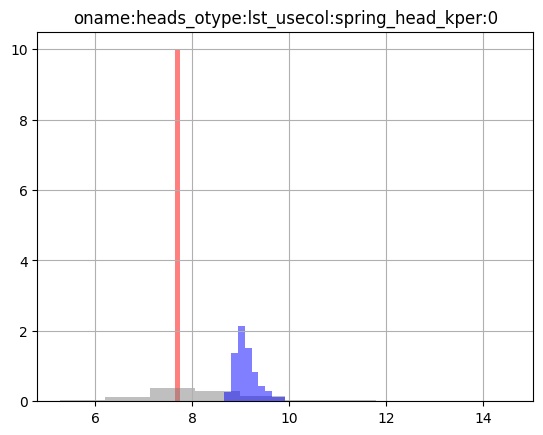

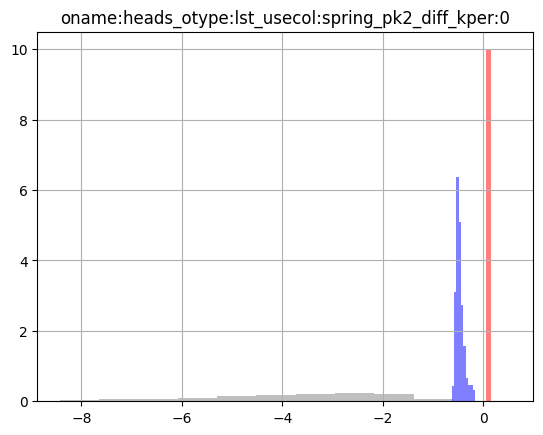

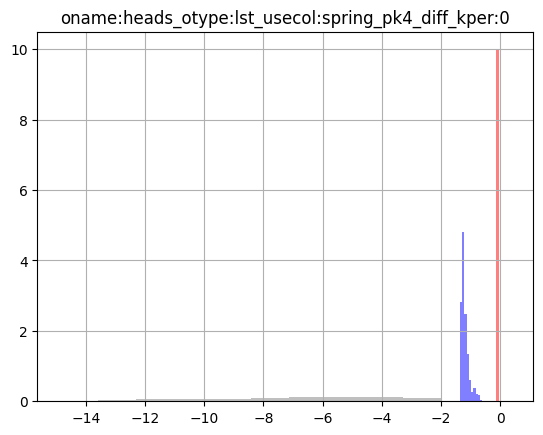

In [49]:
# plot obs+noise vs prior mean
for col in pr_oe.columns:
    # plot the prior and posterior ensemble distributions
    fig, ax = plt.subplots(1, 1)
    noise.loc[:, col].hist(ax=ax, fc="r", ec="none", alpha=0.5, density=True)  # posterior blue
    pr_oe.loc[:, col].hist(ax=ax, fc="0.5", ec="none", alpha=0.5, density=True)  # prior grey
    pt_oe.loc[:, col].hist(ax=ax, fc="b", ec="none", alpha=0.5, density=True)  # posterior blue
    ax.set_title(col)
    plt.show()

# Forecasts

In [50]:
pst.forecast_names

['oname:heads_otype:lst_usecol:spring_flux_kper:0',
 'oname:heads_otype:lst_usecol:spring_pk4_diff_kper:0']

In [51]:
def plot_forecast_hist_compare(pt_oe,pr_oe, last_pt_oe=None,last_prior=None ):
        num_plots = len(pst.forecast_names)
        num_cols = 1
        if last_pt_oe!=None:
            num_cols=2
        fig,axes = plt.subplots(num_plots, num_cols, figsize=(5*num_cols,num_plots * 2.5), sharex='row',sharey='row')
        for axs,forecast in zip(axes, pst.forecast_names):
            # plot first column with current outcomes
            if num_cols==1:
                axs=[axs]
            ax = axs[0]
            # just for aesthetics
            bin_cols = [pt_oe.loc[:,forecast], pr_oe.loc[:,forecast],]
            if num_cols>1:
                bin_cols.extend([last_pt_oe.loc[:,forecast],last_prior.loc[:,forecast]])
            bins=np.histogram(pd.concat(bin_cols),
                                         bins=20)[1] #get the bin edges
            pr_oe.loc[:,forecast].hist(facecolor="0.5",alpha=0.5, bins=bins, ax=ax)
            pt_oe.loc[:,forecast].hist(facecolor="b",alpha=0.5, bins=bins, ax=ax)
            ax.set_title(forecast)
            fval = pst.observation_data.loc[forecast,"obsval"]
            ax.plot([fval,fval],ax.get_ylim(),"r-")
            # plot second column with other outcomes
            if num_cols >1:
                ax = axs[1]
                last_prior.loc[:,forecast].hist(facecolor="0.5",alpha=0.5, bins=bins, ax=ax)
                last_pt_oe.loc[:,forecast].hist(facecolor="b",alpha=0.5, bins=bins, ax=ax)
                ax.set_title(forecast)
                fval = pst.observation_data.loc[forecast,"obsval"]
                ax.plot([fval,fval],ax.get_ylim(),"r-")
        # set ax column titles
        if num_cols >1:
            axes.flatten()[0].text(0.5,1.2,"Current Attempt", transform=axes.flatten()[0].transAxes, weight='bold', fontsize=12, horizontalalignment='center')
            axes.flatten()[1].text(0.5,1.2,"Previous Attempt", transform=axes.flatten()[1].transAxes, weight='bold', fontsize=12, horizontalalignment='center')
        fig.tight_layout()
        return fig

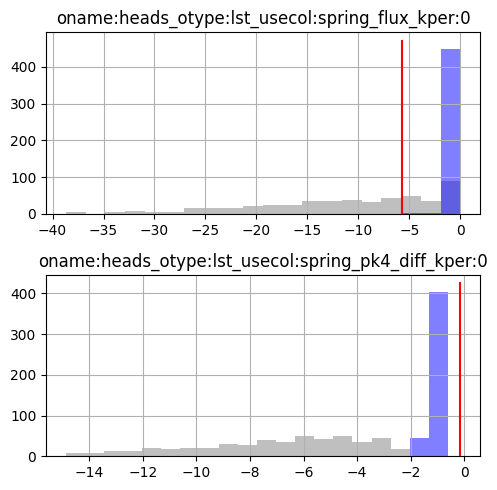

In [52]:
fig = plot_forecast_hist_compare(pt_oe=pt_oe, pr_oe=pr_oe)